# Notebook 03 — Classification Results (3-Class: Walking / Slow Run / Fast Run)

This notebook loads 10-fold CV classification results for the 3-class grouping:

- **Walking** — walk_preferred, walk_predetermined, walk_froude
- **Slow run** — run_predetermined (3.3 m/s fixed), run_froude_a
- **Fast run** — run_froude_b

Produces:
1. **Ablation table** — overall accuracy across GRF-only, Markers-only, Two-Tower
2. **Per-class accuracy** — which category is hardest to classify?
3. **Confusion matrix** — where do misclassifications fall?
4. **Per-fold accuracy distribution** — variability across folds
5. **Attribution analysis** — which part of the gait cycle drives each prediction?

Run `scripts/run_cv.py` for all three model variants before executing:
```bash
uv run python scripts/run_cv.py --task classification --n-classes 3 --model grf_only --subsample-frac 0.25
uv run python scripts/run_cv.py --task classification --n-classes 3 --model marker_only --subsample-frac 0.25
uv run python scripts/run_cv.py --task classification --n-classes 3 --model two_tower --subsample-frac 0.25
```

> **Note:** Results in this notebook were generated with `--subsample-frac 0.25`
> (25% of cycles per subject/condition, stratified) due to memory constraints.
> `--n-folds 10` is the default.

## Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch.utils.data import DataLoader

sys.path.insert(0, str(Path.cwd().parent))

from gait_ml.dataset import (
    LABEL_CONDITIONS_3,
    LABEL_MAP_6_TO_3,
    N_CLASSES_3,
    GaitCycleDataset,
    kfold_splits,
    load_manifest,
)
from gait_ml.models import (
    GRFOnlyClassifier,
    MarkerOnlyClassifier,
    TwoTowerClassifier,
)
from gait_ml.train import evaluate, get_device

PROCESSED_DIR = Path("../data/processed")
RESULTS_DIR   = Path("../results")
CKPT_DIR      = Path("../checkpoints")

DEVICE = get_device()
print(f"Device: {DEVICE}")

N_CLASSES = N_CLASSES_3   # 3: walking / slow_run / fast_run
N_FOLDS   = 10            # must match --n-folds used during training

COND_ORDER = ["walking", "slow_run", "fast_run"]
COND_DISPLAY = {
    "walking":  "Walking",
    "slow_run": "Slow Run\n(Fixed + Froude A)",
    "fast_run": "Fast Run\n(Froude B)",
}
MODEL_DISPLAY = {
    "grf_only":    "GRF only",
    "marker_only": "Markers only",
    "two_tower":   "Two-Tower (fused)",
}
MODALITY_FOR_MODEL = {
    "grf_only":    "grf",
    "marker_only": "markers",
    "two_tower":   "both",
}
MODEL_CLASSES = {
    "grf_only":    lambda: GRFOnlyClassifier(n_classes=N_CLASSES),
    "marker_only": lambda: MarkerOnlyClassifier(n_classes=N_CLASSES),
    "two_tower":   lambda: TwoTowerClassifier(n_classes=N_CLASSES),
}

sns.set_theme(style="whitegrid", font_scale=1.2)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("Setup complete.")

Device: mps
Setup complete.


## 1. Load CV results

In [2]:
model_names = ["grf_only", "marker_only", "two_tower"]
results: dict[str, pd.DataFrame] = {}

for name in model_names:
    path = RESULTS_DIR / f"{N_FOLDS}fold_classification_3class_{name}.csv"
    if path.exists():
        results[name] = pd.read_csv(path)
        print(f"{MODEL_DISPLAY[name]:25s}  {len(results[name])} folds")
    else:
        print(f"[missing] {path}")

assert results, (
    f"No results found — run scripts/run_cv.py "
    f"--task classification --n-classes 3 --n-folds {N_FOLDS} first."
)

GRF only                   10 folds
Markers only               10 folds
Two-Tower (fused)          10 folds


## 2. Ablation table

Mean ± standard deviation of overall accuracy across all CV folds.

In [3]:
rows = []
for name, df in results.items():
    acc = df["overall_acc"]
    rows.append({
        "Model":    MODEL_DISPLAY[name],
        "Mean acc": acc.mean(),
        "Std":      acc.std(),
        "Min":      acc.min(),
        "Max":      acc.max(),
        "N folds":  len(df),
    })

ablation = pd.DataFrame(rows).set_index("Model")
ablation_pct = ablation.copy()
for col in ["Mean acc", "Std", "Min", "Max"]:
    ablation_pct[col] = ablation_pct[col].map("{:.1%}".format)

print(f"Ablation table ({N_FOLDS}-fold CV):")
print(ablation_pct.to_string())

Ablation table (10-fold CV):
                  Mean acc   Std    Min     Max  N folds
Model                                                   
GRF only             98.9%  0.9%  97.4%   99.8%       10
Markers only         99.8%  0.6%  98.1%  100.0%       10
Two-Tower (fused)    99.7%  0.8%  97.6%  100.0%       10


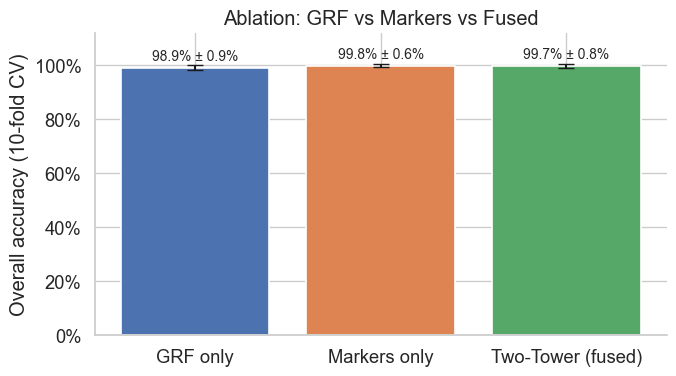

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))

names  = list(results.keys())
means  = [results[n]["overall_acc"].mean() for n in names]
stds   = [results[n]["overall_acc"].std()  for n in names]
labels = [MODEL_DISPLAY[n] for n in names]
colors = ["#4C72B0", "#DD8452", "#55A868"]

bars = ax.bar(labels, means, yerr=stds, capsize=6, color=colors,
              edgecolor="white", linewidth=1.2, error_kw=dict(linewidth=1.5))

for bar, m, s in zip(bars, means, stds):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + s + 0.01,
        f"{m:.1%} \u00b1 {s:.1%}",
        ha="center", va="bottom", fontsize=10,
    )

ax.set_ylabel(f"Overall accuracy ({N_FOLDS}-fold CV)")
ax.set_title("Ablation: GRF vs Markers vs Fused")
ax.set_ylim(0, 1.12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
sns.despine()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ablation_bar_classification.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Per-class accuracy

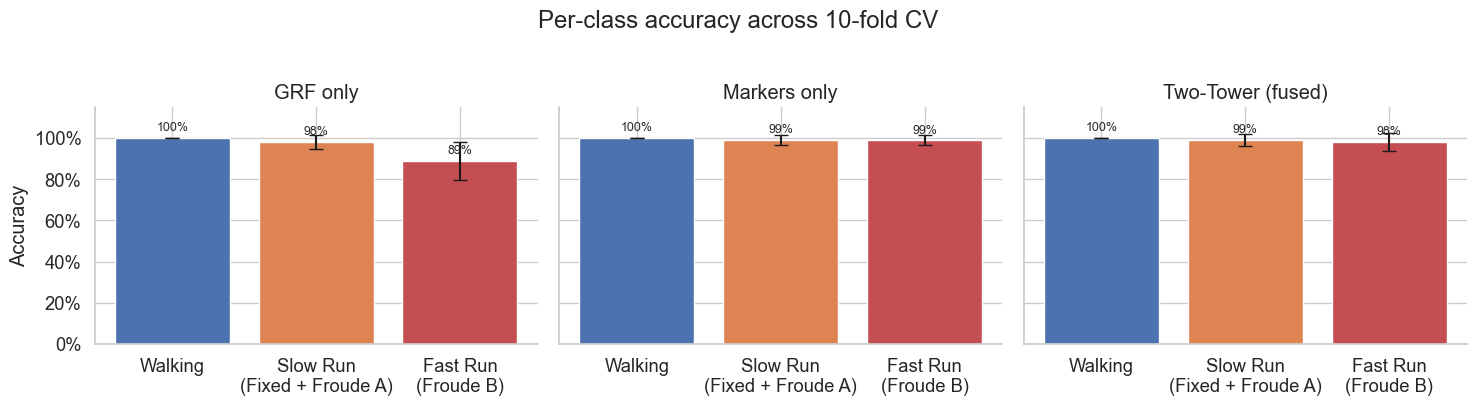

In [5]:
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4), sharey=True)
if len(results) == 1:
    axes = [axes]

for ax, (name, df) in zip(axes, results.items()):
    acc_cols = [f"acc_{c}" for c in COND_ORDER if f"acc_{c}" in df.columns]
    means = [df[c].mean() for c in acc_cols]
    stds  = [df[c].std()  for c in acc_cols]
    xlabels = [COND_DISPLAY[c.replace("acc_", "")] for c in acc_cols]
    colors = ["#4C72B0", "#DD8452", "#C44E52"]

    bars = ax.bar(xlabels, means, yerr=stds, capsize=5,
                  color=colors[:len(acc_cols)], edgecolor="white", linewidth=1)
    ax.set_title(MODEL_DISPLAY[name])
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_ylabel("Accuracy" if ax == axes[0] else "")
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{m:.0%}", ha="center", va="bottom", fontsize=9)

fig.suptitle(f"Per-class accuracy across {N_FOLDS}-fold CV", y=1.02)
sns.despine()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "per_class_accuracy_3class.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Confusion matrix

Accumulated across all 10 held-out folds. The key diagnostic: off-diagonal
entries between walking and running indicate a pipeline problem; confusion
between slow run and fast run is expected and biologically meaningful.

In [6]:
def build_confusion_matrix(model_name: str) -> np.ndarray:
    """Accumulate predictions across all CV folds for model_name."""
    manifest = load_manifest(PROCESSED_DIR)
    folds = kfold_splits(manifest, N_FOLDS)
    modality = MODALITY_FOR_MODEL[model_name]
    conf = np.zeros((N_CLASSES, N_CLASSES), dtype=int)

    for fold_idx, (_, test_df, _) in enumerate(folds):
        ckpt = CKPT_DIR / "classification_3class" / model_name / f"fold_{fold_idx}" / "best.pt"
        if not ckpt.exists():
            print(f"  [skip] no checkpoint for fold_{fold_idx}")
            continue

        ds = GaitCycleDataset(test_df, PROCESSED_DIR, modality=modality,
                              label_map=LABEL_MAP_6_TO_3)
        loader = DataLoader(ds, batch_size=256, shuffle=False)

        model = MODEL_CLASSES[model_name]()
        model.load_state_dict(torch.load(ckpt, weights_only=True, map_location=DEVICE))
        model = model.to(DEVICE).eval()

        with torch.no_grad():
            for grf, markers, labels in loader:
                preds = model(grf.to(DEVICE), markers.to(DEVICE)).argmax(dim=1).cpu().numpy()
                for true, pred in zip(labels.numpy(), preds):
                    conf[true, pred] += 1

    return conf


print("Ready. Run the next cell to build confusion matrices.")

Ready. Run the next cell to build confusion matrices.


Building confusion matrix: GRF only ... done  (total predictions: 42457)


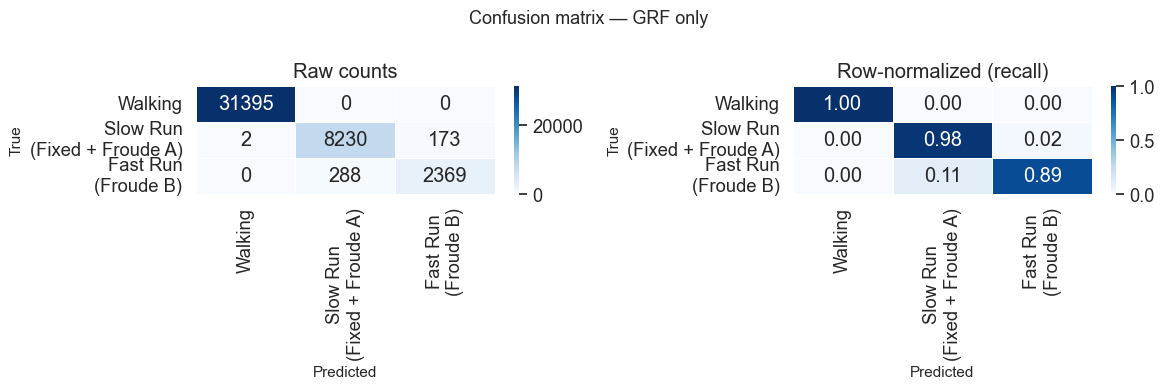

Building confusion matrix: Markers only ... done  (total predictions: 42457)


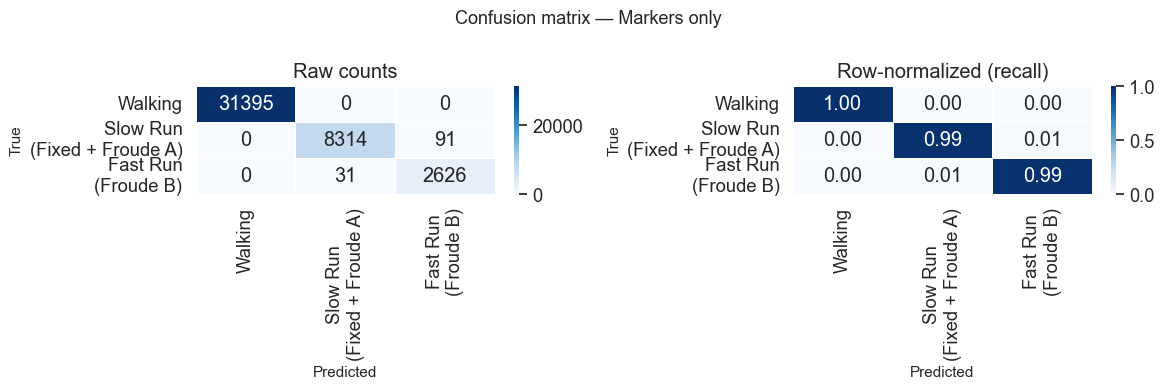

Building confusion matrix: Two-Tower (fused) ... done  (total predictions: 42457)


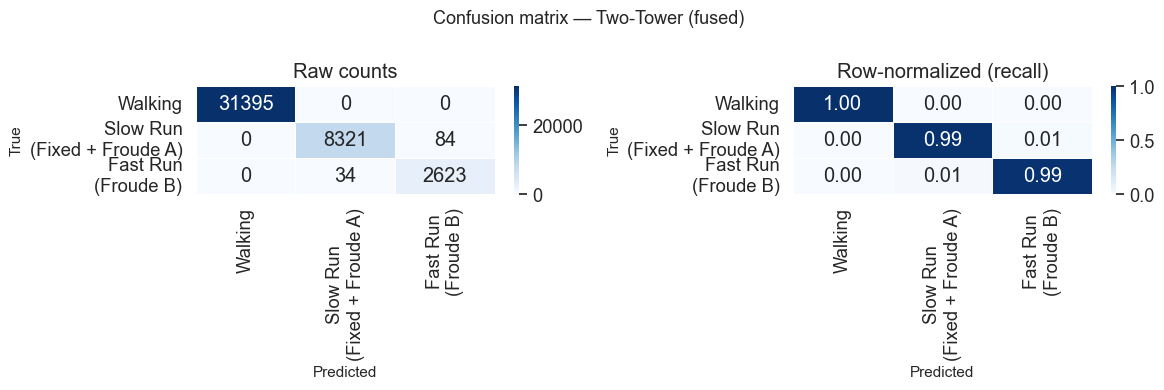

In [7]:
tick_labels = [COND_DISPLAY[c] for c in COND_ORDER]

for model_name in [n for n in model_names if n in results]:
    print(f"Building confusion matrix: {MODEL_DISPLAY[model_name]} ...", end=" ", flush=True)
    conf = build_confusion_matrix(model_name)
    print(f"done  (total predictions: {conf.sum()})")

    conf_norm = conf.astype(float) / conf.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, (data, title, fmt) in zip(axes, [
        (conf,      "Raw counts",              "d"),
        (conf_norm, "Row-normalized (recall)", ".2f"),
    ]):
        sns.heatmap(data, ax=ax, xticklabels=tick_labels, yticklabels=tick_labels,
                    annot=True, fmt=fmt, cmap="Blues",
                    linewidths=0.5, linecolor="white",
                    vmin=0, vmax=(1 if fmt == ".2f" else None))
        ax.set_xlabel("Predicted", fontsize=11)
        ax.set_ylabel("True", fontsize=11)
        ax.set_title(title)

    fig.suptitle(f"Confusion matrix — {MODEL_DISPLAY[model_name]}", fontsize=13)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"confusion_3class_{model_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 5. Per-fold accuracy distribution

Box plot showing variability across folds. High variance may indicate that the
model generalises well to some body types but not others.

/var/folders/r7/6qdg6hx128vf3nkqy015p1j00000gn/T/ipykernel_85951/207402194.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=long_df, x="Model", y="Accuracy",


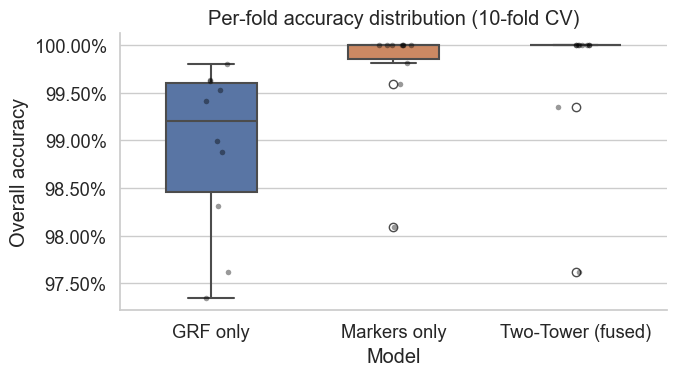

In [8]:
long_rows = []
for name, df in results.items():
    for _, row in df.iterrows():
        long_rows.append({"Model": MODEL_DISPLAY[name], "Accuracy": row["overall_acc"]})

long_df = pd.DataFrame(long_rows)

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=long_df, x="Model", y="Accuracy",
            palette=["#4C72B0", "#DD8452", "#55A868"],
            width=0.5, linewidth=1.5, ax=ax)
sns.stripplot(data=long_df, x="Model", y="Accuracy",
              color="black", alpha=0.4, size=4, jitter=True, ax=ax)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylabel("Overall accuracy")
ax.set_title(f"Per-fold accuracy distribution ({N_FOLDS}-fold CV)")
sns.despine()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fold_distribution_classification_3class.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Attribution analysis (Integrated Gradients)

Which part of the gait cycle does the model rely on to distinguish each class?

**Integrated gradients** (Sundararajan et al., 2017) attribute the model's
output to each input feature by accumulating gradients along a straight path
from a baseline (zeros = no signal) to the actual input. The result has the
same shape as the input — `(3, 101)` for GRF, `(90, 101)` for markers — and
can be read as "how much did each time point and channel contribute to this
prediction?"

Attributions are computed on the held-out test cycles for each fold, then
averaged within each class. Large positive values at a time point mean the
model was pushing toward that class at that moment in the cycle.

This is also a diagnostic for the slow vs. fast run question: if the
attribution profiles for those two classes look nearly identical, the model has
no reliable waveform signal to tell them apart.

In [10]:
from captum.attr import IntegratedGradients

# Subsampling budget: max cycles per class drawn from each fold's test set.
# 50/class is typically enough for stable mean attributions; reduce further if slow.
N_ATTR_CYCLES = 50

# Segment groupings for marker attribution summary (index into 30-marker list)
MARKER_SEGMENTS = {
    "Pelvis":      list(range(0, 4)),
    "Left thigh":  list(range(4, 8)),
    "Left shank":  list(range(8, 12)),
    "Left foot":   list(range(12, 17)),
    "Right thigh": list(range(17, 21)),
    "Right shank": list(range(21, 25)),
    "Right foot":  list(range(25, 30)),
}
GRF_CHANNEL_NAMES = ["Fz_L", "Fz_R", "Fz_total"]
TIME_AXIS = np.linspace(0, 100, 101)


def _ig_for_modality(model, grf, markers, modality, target_cls):
    """Integrated gradients, differentiating only w.r.t. the active modality.

    GRF-only and Marker-only models ignore one input entirely, so asking
    Captum to differentiate w.r.t. the unused tensor raises 'not used in
    graph'. Fix: wrap the model in a closure that holds the unused input
    fixed, and only pass the active input to IG.
    """
    if modality == "grf":
        def fwd(g): return model(g, markers)
        attr_g = IntegratedGradients(fwd).attribute(
            grf, baselines=torch.zeros_like(grf),
            target=target_cls, n_steps=25, internal_batch_size=32,
        )
        return attr_g.detach(), torch.zeros_like(markers)
    elif modality == "markers":
        def fwd(m): return model(grf, m)
        attr_m = IntegratedGradients(fwd).attribute(
            markers, baselines=torch.zeros_like(markers),
            target=target_cls, n_steps=25, internal_batch_size=32,
        )
        return torch.zeros_like(grf), attr_m.detach()
    else:  # both — differentiate w.r.t. both inputs simultaneously
        attr_g, attr_m = IntegratedGradients(model).attribute(
            inputs=(grf, markers),
            baselines=(torch.zeros_like(grf), torch.zeros_like(markers)),
            target=target_cls, n_steps=25, internal_batch_size=32,
        )
        return attr_g.detach(), attr_m.detach()


def compute_class_attributions(model_name: str) -> dict:
    """Return mean integrated-gradient attributions per class across all CV folds."""
    manifest = load_manifest(PROCESSED_DIR)
    folds = kfold_splits(manifest, N_FOLDS)
    modality = MODALITY_FOR_MODEL[model_name]
    rng = np.random.default_rng(42)

    grf_attr_sum     = np.zeros((N_CLASSES, 3,  101))
    marker_attr_sum  = np.zeros((N_CLASSES, 90, 101))
    grf_input_sum    = np.zeros((N_CLASSES, 3,  101))
    marker_input_sum = np.zeros((N_CLASSES, 90, 101))
    class_counts     = np.zeros(N_CLASSES, dtype=int)

    for fold_idx, (_, test_df, _) in enumerate(folds):
        ckpt = CKPT_DIR / "classification_3class" / model_name / f"fold_{fold_idx}" / "best.pt"
        if not ckpt.exists():
            continue

        ds = GaitCycleDataset(test_df, PROCESSED_DIR, modality=modality,
                              label_map=LABEL_MAP_6_TO_3)

        model = MODEL_CLASSES[model_name]()
        model.load_state_dict(torch.load(ckpt, weights_only=True, map_location="cpu"))
        model = model.eval()

        # Collect the full fold test set into memory, then subsample per class.
        # This avoids running IG on every batch independently (wasteful) and lets
        # us draw a balanced sample across classes before any gradient computation.
        all_grf, all_markers, all_labels = [], [], []
        with torch.no_grad():
            for grf_batch, marker_batch, label_batch in DataLoader(ds, batch_size=256, shuffle=False):
                all_grf.append(grf_batch)
                all_markers.append(marker_batch)
                all_labels.append(label_batch)
        all_grf     = torch.cat(all_grf)
        all_markers = torch.cat(all_markers)
        all_labels  = torch.cat(all_labels)

        for cls in range(N_CLASSES):
            cls_indices = (all_labels == cls).nonzero(as_tuple=True)[0].numpy()
            if len(cls_indices) == 0:
                continue
            chosen = rng.choice(cls_indices, size=min(N_ATTR_CYCLES, len(cls_indices)), replace=False)
            chosen = torch.from_numpy(chosen)

            grf_cls    = all_grf[chosen].requires_grad_(True)
            marker_cls = all_markers[chosen].requires_grad_(True)

            attr_grf, attr_markers = _ig_for_modality(model, grf_cls, marker_cls, modality, cls)
            n = len(chosen)
            grf_attr_sum[cls]     += attr_grf.numpy().sum(axis=0)
            marker_attr_sum[cls]  += attr_markers.numpy().sum(axis=0)
            grf_input_sum[cls]    += grf_cls.detach().numpy().sum(axis=0)
            marker_input_sum[cls] += marker_cls.detach().numpy().sum(axis=0)
            class_counts[cls]     += n

    counts = class_counts[:, None, None].clip(min=1)
    return {
        "grf":                grf_attr_sum    / counts,
        "markers":            marker_attr_sum / counts,
        "grf_mean_input":     grf_input_sum   / counts,
        "markers_mean_input": marker_input_sum / counts,
    }


attr_results: dict[str, dict] = {}
for name in [n for n in model_names if n in results]:
    print(f"Computing attributions: {MODEL_DISPLAY[name]} ...", end=" ", flush=True)
    attr_results[name] = compute_class_attributions(name)
    print("done")

Computing attributions: GRF only ... 

/Users/mariafox/Documents/GitHub/gait-ml/.venv/lib/python3.14/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 50 equal to the number of examples.
  warnings.warn(


done
Computing attributions: Markers only ... 

/Users/mariafox/Documents/GitHub/gait-ml/.venv/lib/python3.14/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 50 equal to the number of examples.
  warnings.warn(


done
Computing attributions: Two-Tower (fused) ... 

/Users/mariafox/Documents/GitHub/gait-ml/.venv/lib/python3.14/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 50 equal to the number of examples.
  warnings.warn(


done


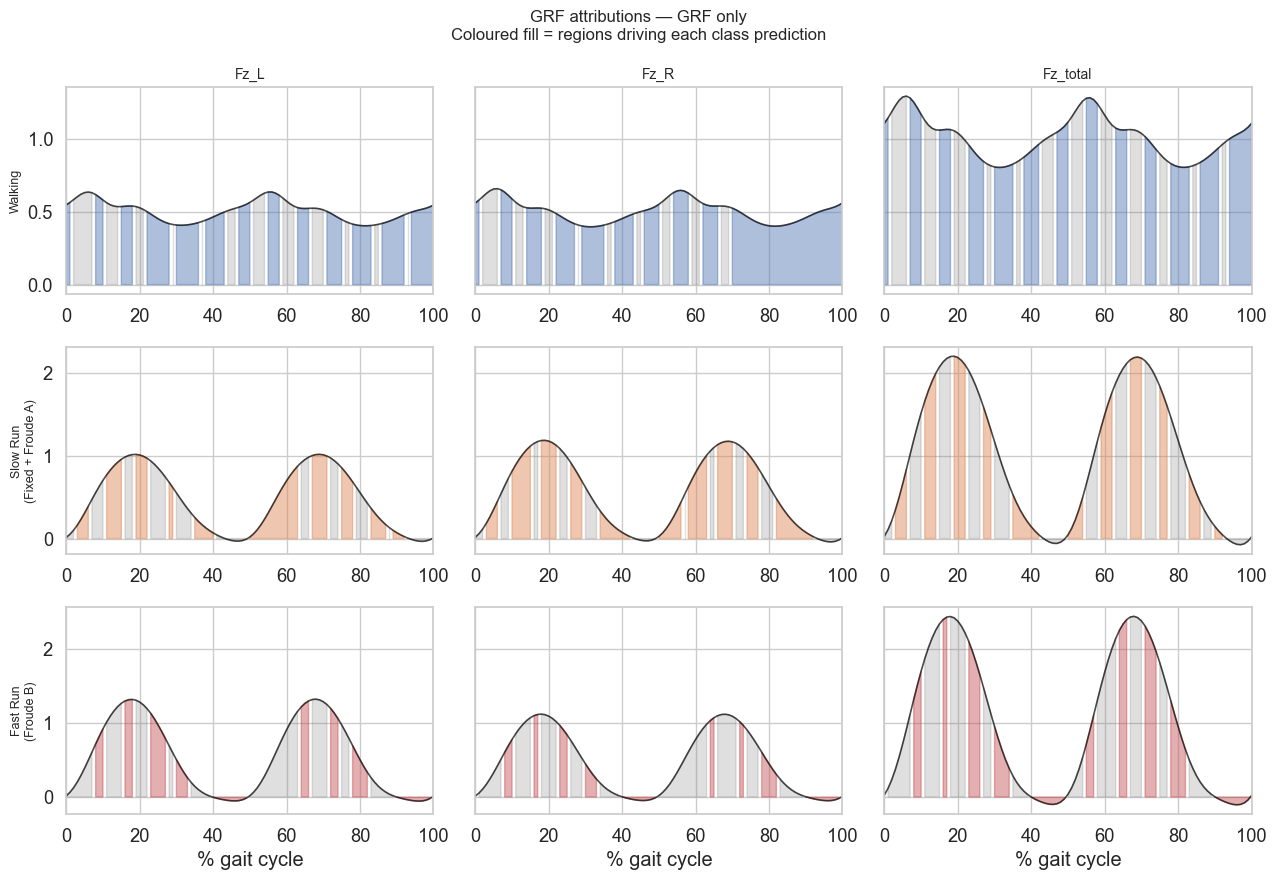

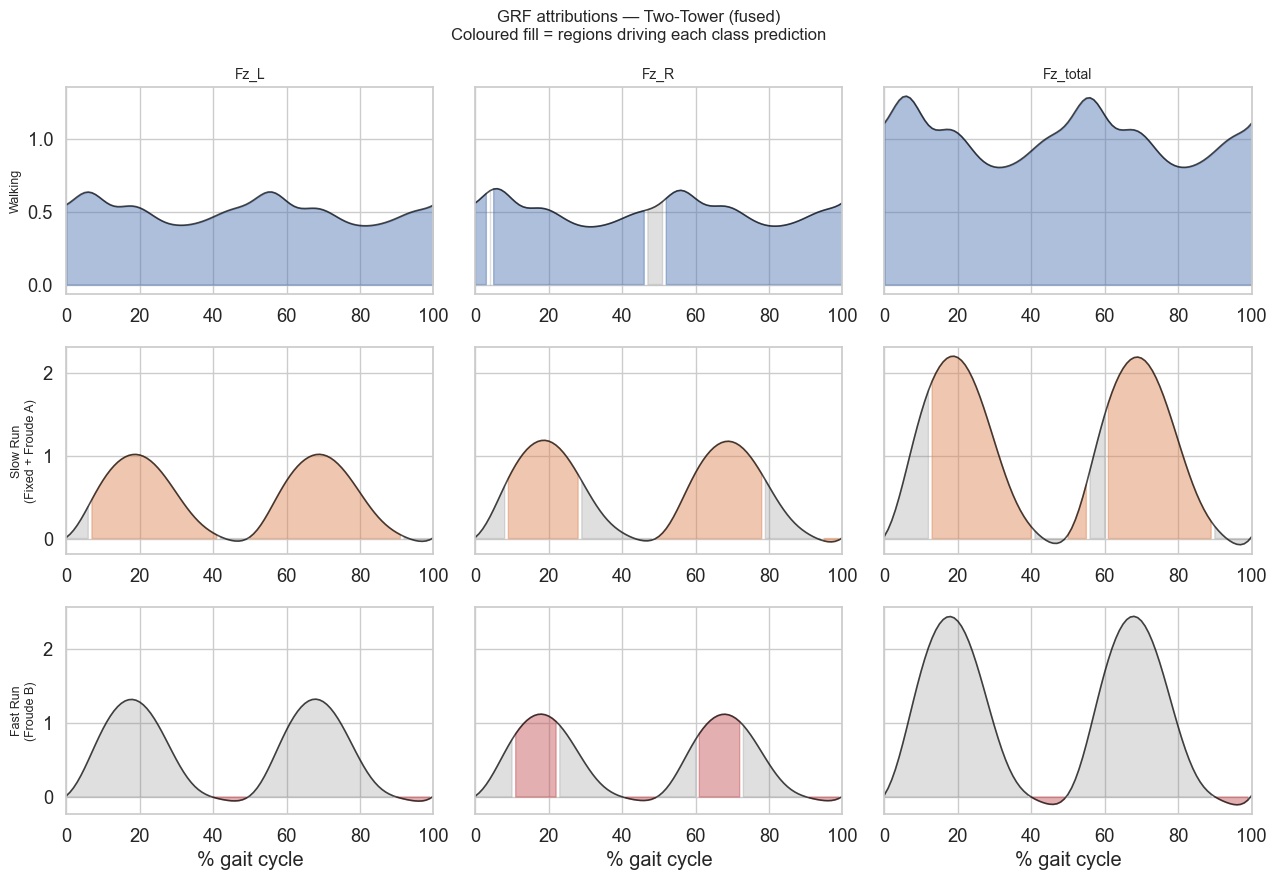

In [11]:
# GRF attribution: one row per class, one column per GRF channel
# Background = mean waveform; colour fill = attribution magnitude

class_colors = ["#4C72B0", "#DD8452", "#C44E52"]

for model_name, attrs in attr_results.items():
    if MODALITY_FOR_MODEL[model_name] == "markers":
        continue  # GRF attributions are zeros for marker-only model

    grf_attr  = attrs["grf"]            # (N_CLASSES, 3, 101)
    grf_input = attrs["grf_mean_input"] # (N_CLASSES, 3, 101)

    fig, axes = plt.subplots(N_CLASSES, 3, figsize=(13, 3 * N_CLASSES), sharey="row")

    for cls_idx, cls_name in enumerate(COND_ORDER):
        for ch_idx, ch_name in enumerate(GRF_CHANNEL_NAMES):
            ax = axes[cls_idx, ch_idx]
            waveform = grf_input[cls_idx, ch_idx]
            attr     = grf_attr[cls_idx, ch_idx]

            scale = np.abs(attr).max() or 1.0
            attr_norm = attr / scale

            ax.plot(TIME_AXIS, waveform, color="black", linewidth=1.2, alpha=0.7)
            ax.fill_between(TIME_AXIS, waveform,
                            where=(attr_norm > 0),
                            alpha=0.45, color=class_colors[cls_idx],
                            label="positive attr")
            ax.fill_between(TIME_AXIS, waveform,
                            where=(attr_norm < 0),
                            alpha=0.25, color="gray",
                            label="negative attr")
            ax.set_xlim(0, 100)
            if cls_idx == 0:
                ax.set_title(ch_name, fontsize=10)
            if ch_idx == 0:
                ax.set_ylabel(COND_DISPLAY[cls_name], fontsize=9)
            if cls_idx == N_CLASSES - 1:
                ax.set_xlabel("% gait cycle")

    fig.suptitle(f"GRF attributions — {MODEL_DISPLAY[model_name]}\n"
                 f"Coloured fill = regions driving each class prediction",
                 fontsize=12)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"attr_grf_{model_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

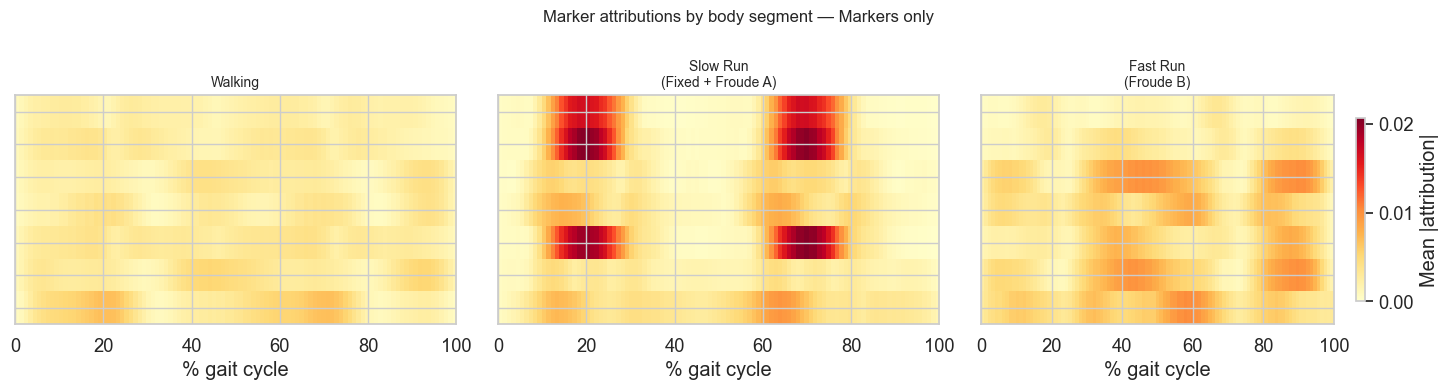

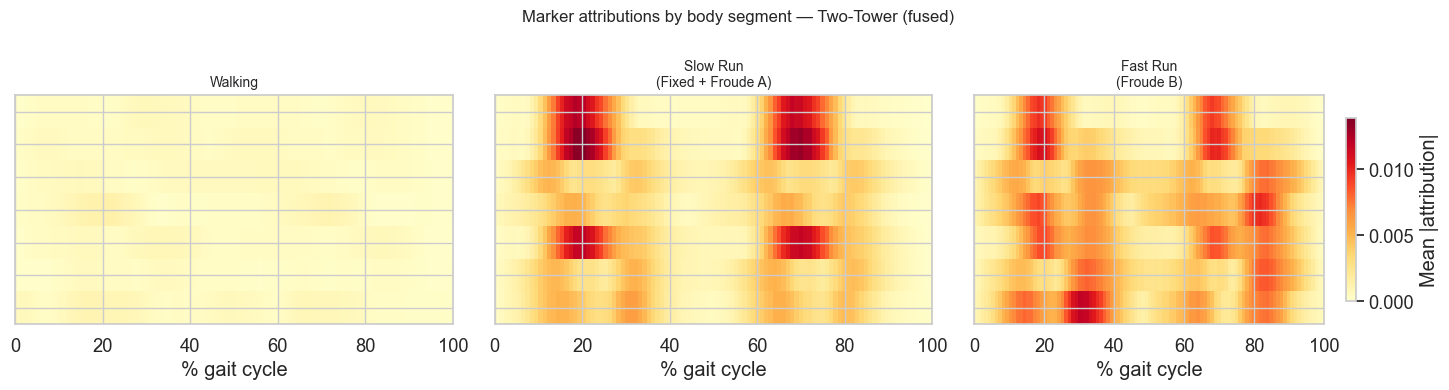

In [12]:
# Marker attributions: aggregate by body segment, show as heatmap (segment x time)
# Each cell = mean absolute attribution across all markers in that segment

for model_name, attrs in attr_results.items():
    if MODALITY_FOR_MODEL[model_name] == "grf":
        continue  # marker attributions are zeros for GRF-only model

    marker_attr = attrs["markers"]  # (N_CLASSES, 90, 101)

    seg_names = list(MARKER_SEGMENTS.keys())
    seg_attr = np.zeros((N_CLASSES, len(seg_names), 101))
    for s_idx, (seg_name, marker_idxs) in enumerate(MARKER_SEGMENTS.items()):
        ch_idxs = [m * 3 + ax for m in marker_idxs for ax in range(3)]
        seg_attr[:, s_idx, :] = np.abs(marker_attr[:, ch_idxs, :]).mean(axis=1)

    fig, axes = plt.subplots(1, N_CLASSES, figsize=(5 * N_CLASSES, 4), sharey=True)

    vmax = seg_attr.max()
    for cls_idx, cls_name in enumerate(COND_ORDER):
        ax = axes[cls_idx]
        im = ax.imshow(seg_attr[cls_idx], aspect="auto", origin="upper",
                       extent=[0, 100, len(seg_names) - 0.5, -0.5],
                       cmap="YlOrRd", vmin=0, vmax=vmax)
        ax.set_yticks(range(len(seg_names)))
        ax.set_yticklabels(seg_names if cls_idx == 0 else [], fontsize=9)
        ax.set_xlabel("% gait cycle")
        ax.set_title(COND_DISPLAY[cls_name], fontsize=10)

    fig.colorbar(im, ax=axes[-1], label="Mean |attribution|", shrink=0.8)
    fig.suptitle(f"Marker attributions by body segment — {MODEL_DISPLAY[model_name]}",
                 fontsize=12)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"attr_markers_{model_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

## Summary

| Check | Expected |
|-------|----------|
| Overall accuracy | > 90% — 3-class problem is much easier than 6-class |
| Walking accuracy | High (> 95%) — large speed gap from running |
| Slow run accuracy | Moderate — fixed-speed and Froude A are close in m/s for many subjects |
| Fast run (Froude B) accuracy | High — Froude B is distinctly faster than the other running conditions |
| Two-Tower > GRF-only | Fusion should help, especially for slow vs fast run |

If slow run and fast run are frequently confused, the speed overlap between
predetermined (3.3 m/s) and Froude A for taller subjects may be the cause —
check per-subject speeds in `d_subjectData.csv`.

The confusion matrix is the key diagnostic: off-diagonal entries between
walking and running classes indicate a pipeline problem; off-diagonal entries
between slow and fast run are expected and biologically meaningful.